In [1]:
import numpy as np
from reader import *
import matplotlib.pyplot as plt
import math
from scipy import interpolate

In [2]:
geo = Reader("drafttube_shapes/baseline1/geo/cone.geo", cascade=False)

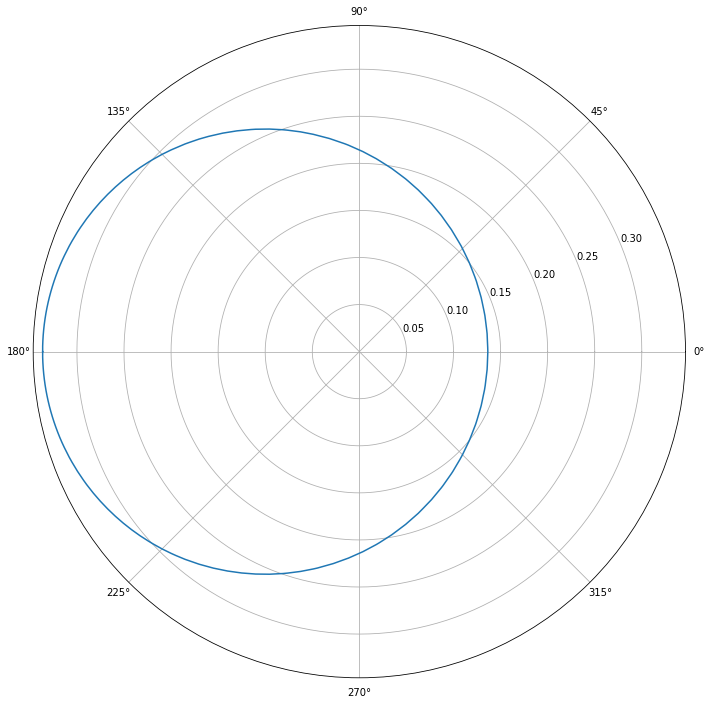

In [38]:
pts = []
for i in range(256):
    pts.append(np.array(geo.collate_xy(i)))
points = np.asarray(pts)

def cart2pol(x, y):
    """Convert a set of cartesian coordinates x, y to polar coordinates r, theta (default to radians)"""
    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)
    return r, theta

t = [i for i in range(-180, 181)]
#print(t)
t_rad = [np.deg2rad(t[i]) for i in range(len(t))]
#print(t_rad)


r_theta = np.array([cart2pol(points[i][0], points[i][1]) for i in range(len(points))])
r_plot = [r_theta[i][0] for i in range(len(r_theta))]
theta_plot_rad = [r_theta[i][1] for i in range(len(r_theta))]
theta_plot_deg = [np.rad2deg(theta_plot_rad[i]) for i in range(len(theta_plot_rad))]

for i in range(len(lst1)):
    if lst1[i] < lst

plt.figure(figsize=(12,12))
#plt.polar(theta_plot_deg, r_plot, '.')
#plt.plot(theta_plot, r_plot, '.')

theta_plot_deg.remove(theta_plot_deg[1])
theta_plot_rad.remove(theta_plot_rad[1])
r_plot.remove(r_plot[1])
#plt.polar(theta_plot_rad, r_plot, '-')

f = interpolate.CubicSpline(theta_plot_rad, r_plot, extrapolate=True)
plt.polar(t_rad, f(t_rad), '-')



# Account for all axis offset
# Use CubicSpline instead of B spline 
# Convert to r theta first and interpolate with that


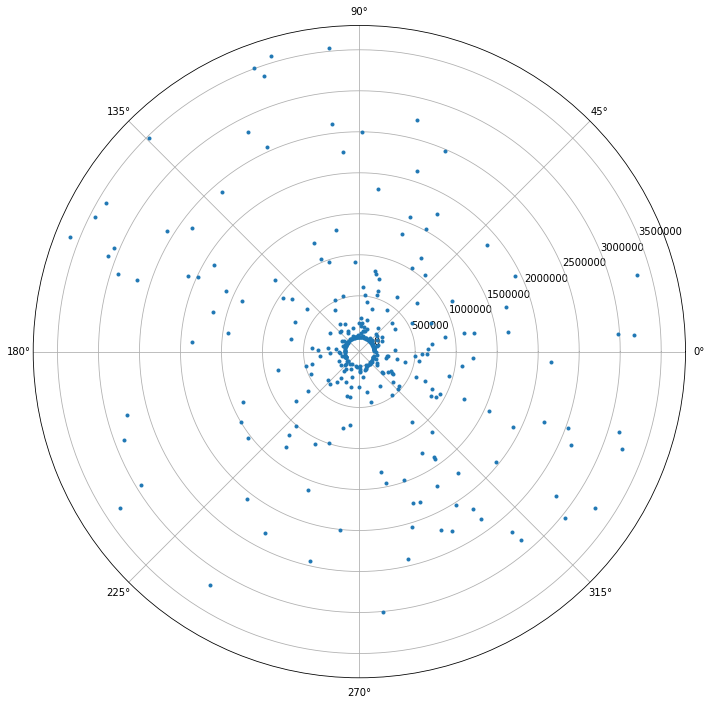

In [7]:
x = np.array([r_theta[i][0] for i in range(len(r_theta))]) #np.array([points[i][0] for i in range(len(points))])
y = np.array([r_theta[i][1] for i in range(len(r_theta))]) #np.array([points[i][1] for i in range(len(points))])
plt.figure(figsize=(12,12))
#plt.plot(x, y, '.')
# append the starting x,y coordinates
x = np.r_[x, x[0]]
y = np.r_[y, y[0]]
# fit splines to x=f(u) and y=g(u), treating both as periodic. also note that s=0
# is needed in order to force the spline fit to pass through all the input points.
tck, u = interpolate.splprep([x, y], s=0, per=True)
# evaluate the spline fits for 10000 evenly spaced distance values
xi, yi = interpolate.splev(np.linspace(0, 2*math.pi, 360), tck) # 10000 points makes this accurate enough to be able to narrow down
plt.polar(xi, yi, '.')
r_theta = np.array([cart2pol(x[i], y[i]) for i in range(len(points))])
#print(r_theta)

In [60]:
def cart2pol(x, y):
    """Convert a set of cartesian coordinates x, y to polar coordinates r, theta (default to radians)"""
    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)
    return r, theta

def closest(lst, K):
    """Return the nearest value to integer K in a list of floating point values lst"""
    ind = min(range(len(lst)), key = lambda i: abs(lst[i] - K))
    return [lst[ind - 1], lst[ind]]

def interpolate_polar(x, y):
    """Take the our i = 10000 interpolated points in Cartesian (x, y) space and return each 
    (r, theta) vector from [1, 360] degrees (360 = 0). Note that these vectors are not ordered.
    FIX: The indexes are messed up - [90] is 270deg, [180] is 360deg, [270] is 90deg, [0] is 180deg
    """
    pol = np.asarray([cart2pol(y[i], x[i]) for i in range(len(x))]) # Convert to an (r, theta) numpy array, default in radians
    pol_f = np.ndarray.flatten(pol) # Flatten to be able to manipulate and still be able to re-pair later on
    for i in range(1, len(pol_f), 2): # Convert radians to degrees
        deg = np.rad2deg(pol_f[i])
        pol_f[i] = deg
    degs = [] # List to append re-pair
    for i in range(-180, 180): # Find the closest discreet deg value for 360deg out of 10,000 points
        degs.append(closest(pol_f, i))
    for i in range(len(degs)):
        r = int(round(degs[i][1])) # Convert degree values to integers
        degs[i][1] = r
        if degs[i][1] <= 0: # Convert -180:180 to 0:360
            degs[i][1] += 360
    return degs

In [41]:
n = interpolate_polar(xi, yi)

270.0
360.0
90.0
180.0


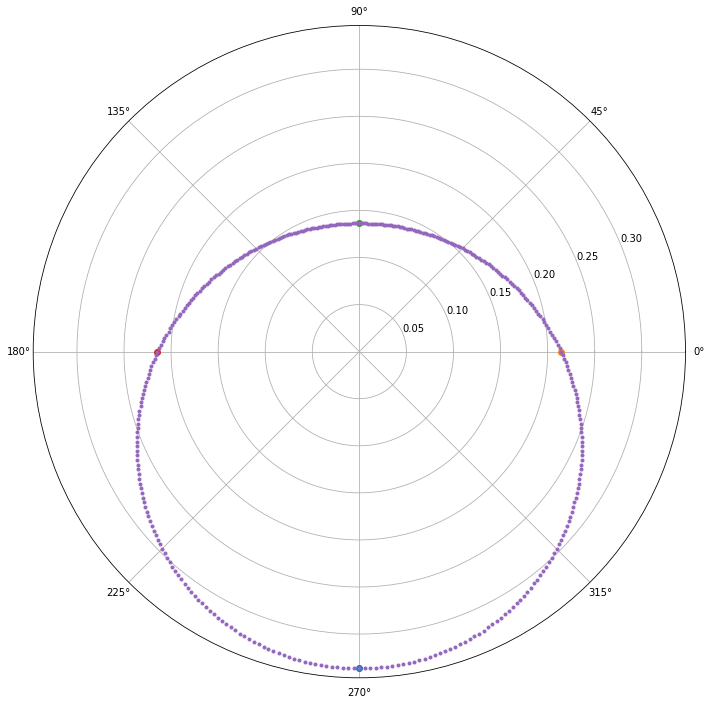

In [42]:
plt.figure(figsize=(12,12))

r_plot = [n[i][0] for i in range(len(n))]
theta_plot = [np.deg2rad(n[i][1]) for i in range(len(n))]

print(np.rad2deg(theta_plot[90]))
print(np.rad2deg(theta_plot[180]))
print(np.rad2deg(theta_plot[270]))
print(np.rad2deg(theta_plot[0]))

plt.polar(theta_plot[90], r_plot[90], 'o')
plt.polar(theta_plot[180], r_plot[180], 'o')
plt.polar(theta_plot[270], r_plot[270], 'o')
plt.polar(theta_plot[0], r_plot[0], 'o')
plt.polar(theta_plot, r_plot, '.')